In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [217]:
df = pd.read_csv("./water_quality.csv")

In [218]:
df.columns

Index(['Well_ID', 'State', 'District', 'Block', 'Village', 'Latitude',
       'Longitude', 'Year', 'pH', 'EC', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3',
       'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'TDS', 'WQI',
       'Water Quality Classification'],
      dtype='str')

In [219]:
total_records = len(df)
total_records

19029

In [220]:
df.dtypes

Well_ID                             str
State                               str
District                            str
Block                               str
Village                             str
Latitude                        float64
Longitude                       float64
Year                              int64
pH                              float64
EC                              float64
CO3                             float64
HCO3                            float64
Cl                              float64
SO4                             float64
NO3                             float64
TH                              float64
Ca                              float64
Mg                              float64
Na                              float64
K                               float64
F                               float64
TDS                               int64
WQI                             float64
Water Quality Classification        str
dtype: object

In [221]:
df.isnull().sum()

Well_ID                         3785
State                              0
District                           0
Block                           1119
Village                            1
Latitude                         389
Longitude                        390
Year                               0
pH                                 0
EC                                 0
CO3                                0
HCO3                               0
Cl                                 0
SO4                                0
NO3                                0
TH                                 0
Ca                                 0
Mg                                 0
Na                                 0
K                                  0
F                                  0
TDS                                0
WQI                                0
Water Quality Classification       0
dtype: int64

In [222]:
df.head()

,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
0,W232200071580001,Gujarat,Ahmedabad,Mandal,Dalod,NaN,NaN,2020,8.20,16640.0,...,26.00,1451.0,152.0,260.0,3535.0,45.0,1.00,11149,4361.44080,Unsuitable for Drinking
1,W254029084355301,Himachal Pradesh,Solan,Nallagarh,JAGATPUR,31.1594,76.678500,2019,8.44,299.0,...,2.70,84.0,17.0,10.0,39.0,2.4,0.20,262,85.80466,Good
2,W193530074180001,Maharashtra,Ahmednagar,SANGAMNER,Kokangaon,74.3000,19.591667,2022,7.90,1315.0,...,18.20,465.0,80.2,64.4,88.3,1.6,0.53,372,280.04130,Very Poor yet Drinkable
3,W231620072033001,Gujarat,Ahmedabad,Viramgam,Endla,NaN,NaN,2020,7.40,715.0,...,0.23,280.0,56.0,34.0,47.0,11.0,0.46,479,195.11649,Poor
4,W251908084361501,Himachal Pradesh,Solan,Nallagarh,BARUNA,31.1540,76.638400,2019,8.40,270.0,...,10.00,116.0,10.0,18.0,23.0,1.0,0.12,262,81.77860,Good


## Village Feature

### Case Sensitiveness

In [223]:
len(df["Village"].unique())

11211

In [224]:
# treating case sensitiveness
len(set([i.lower() for i in df["Village"] if i is not np.nan]))

10481

In [225]:
df["Village"] = df["Village"].str.lower()

In [226]:
len(df["Village"].unique())

10482

### Treating null values

In [227]:
df[df["Village"].isna()]

,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
17034,NaN,Maharashtra,Aurangabad,KANNAD,NaN,20.1697,75.1317,2019,7.7,1391.0,...,27.0,345.0,64.0,44.0,78.0,1.22,0.09,904,340.27112,Unsuitable for Drinking


In [228]:
df[(df["State"]=="Maharashtra") & (df["District"]=="Aurangabad") & (df["Block"] == "KANNAD")]

,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
12015,W200205075020501,Maharashtra,Aurangabad,KANNAD,devgaon-1,20.034700,75.034700,2019,7.30,986.0,...,38.0,247.0,54.0,26.0,67.0,0.86,0.03,641,251.04636,Very Poor yet Drinkable
17034,NaN,Maharashtra,Aurangabad,KANNAD,NaN,20.169700,75.131700,2019,7.70,1391.0,...,27.0,345.0,64.0,44.0,78.0,1.22,0.09,904,340.27112,Unsuitable for Drinking
17253,W201600075080001,Maharashtra,Aurangabad,KANNAD,kannad,75.133333,20.266667,2022,7.44,1505.0,...,85.4,595.0,100.2,83.8,64.4,0.70,0.38,887,378.54376,Unsuitable for Drinking
17268,W201000075040001,Maharashtra,Aurangabad,KANNAD,kinnal,75.066667,20.002778,2022,7.52,1403.0,...,52.9,510.0,94.2,66.8,91.2,0.80,0.59,763,349.69898,Unsuitable for Drinking
17274,W200205075020501,Maharashtra,Aurangabad,KANNAD,devgaon-1,75.034722,20.034722,2022,7.70,1354.0,...,67.0,460.0,76.2,65.6,81.0,1.20,0.43,945,362.31580,Unsuitable for Drinking
17286,W201728075161901,Maharashtra,Aurangabad,KANNAD,hasta,75.271944,20.291111,2022,7.77,884.8,...,78.1,345.0,54.1,51.0,23.8,0.70,0.54,765,262.01178,Very Poor yet Drinkable
17340,W201011075075401,Maharashtra,Aurangabad,KANNAD,hatnur1,75.131667,20.169722,2022,7.59,1123.0,...,64.0,395.0,54.1,63.2,48.9,0.70,0.52,600,272.97806,Very Poor yet Drinkable


In [229]:
df.dropna(subset=["Village"], inplace=True)

### Conclusion: We cannot determine the value to use instead of null value (by further drilling down in the dataset), so dropping the null record.

## Well ID

In [230]:
df[df["Well_ID"].isna()].count()

Well_ID                            0
State                           3784
District                        3784
Block                           3284
Village                         3784
Latitude                        3739
Longitude                       3738
Year                            3784
pH                              3784
EC                              3784
CO3                             3784
HCO3                            3784
Cl                              3784
SO4                             3784
NO3                             3784
TH                              3784
Ca                              3784
Mg                              3784
Na                              3784
K                               3784
F                               3784
TDS                             3784
WQI                             3784
Water Quality Classification    3784
dtype: int64

In [231]:
lookup_df = df[df["Well_ID"].notna()].drop_duplicates(subset=["Latitude", "Longitude"]).set_index(["Latitude", "Longitude"])["Well_ID"]

In [232]:
df["Well_ID"] = df.apply(
    lambda x: lookup_df.get((x["Latitude"], x["Longitude"]), x["Well_ID"])
    if pd.isna(x["Well_ID"]) else x["Well_ID"],
    axis=1
)

In [233]:
print("Remaining nulls:", df["Well_ID"].isna().sum())

Remaining nulls: 3614


In [234]:
df.dropna(subset=["Well_ID"], inplace=True)

### Conclusion: We considered latitude and longitude for imputing the missing values. Rest of the missing values have been dropped.

## Dropping latitude/longitude null values directly

In [235]:
df.dropna(subset=["Latitude", "Longitude"], inplace=True)

## Block

### Case Sensitiveness

In [236]:
len(df["Block"].unique()), len(df["Block"].str.lower().unique())

(4010, 3544)

In [237]:
df["Block"] = df["Block"].str.lower()

### Handling null values

In [238]:
df["Block"].isnull().sum()

np.int64(570)

In [239]:
block_lookup_df = df[df["Block"].notna()].drop_duplicates(subset=["Latitude", "Longitude"]).set_index(["Latitude", "Longitude"])["Block"]

In [240]:
df["Block"] = df.apply(lambda x: block_lookup_df.get((x["Latitude"], x["Longitude"]), x["Block"]) if pd.isna(x["Block"]) else x["Block"], axis=1)

In [241]:
df["Block"].isnull().sum()

np.int64(531)

In [242]:
df.dropna(subset=["Block"], inplace=True)

In [243]:
df.reset_index(inplace=True)

### Conclusion: We considered latitude and longitude for imputing the missing values. Rest of the missing values have been dropped.

## Detecting outliers

In [244]:
df.describe()

,index,Latitude,Longitude,Year,pH,EC,CO3,HCO3,Cl,SO4,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI
count,14493.000000,14493.000000,1.449300e+04,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.00000,14493.000000,14493.000000,14493.000000
mean,8593.198096,42.233266,5.144861e+03,2020.533016,7.709810,1170.139990,3.044225,298.453780,163.402633,64.239812,35.946058,324.128804,65.773620,39.298179,108.794780,12.88941,0.605920,712.904644,300.086891
std,5413.494162,29.117081,6.125580e+05,1.305614,0.479403,1233.371138,15.062374,176.431392,320.991939,124.746173,53.911774,280.631859,59.207176,44.846766,183.081751,36.85040,2.055847,665.439260,280.359361
min,1.000000,0.000000,0.000000e+00,2019.000000,3.060000,2.290000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.00000,-0.160000,15.000000,9.694329
25%,4019.000000,21.185556,2.305344e+01,2019.000000,7.450000,553.800000,0.000000,183.000000,35.000000,14.000000,5.300000,170.000000,30.400000,15.800000,29.800000,1.60000,0.210000,375.000000,156.836180
50%,8428.000000,24.362000,7.496900e+01,2021.000000,7.700000,878.000000,0.000000,283.000000,78.000000,31.000000,19.800000,270.000000,52.000000,29.000000,61.000000,3.30000,0.440000,597.000000,238.765800
75%,12201.000000,77.013611,7.846670e+01,2022.000000,7.990000,1375.000000,0.000000,390.500000,170.000000,67.000000,43.900000,395.000000,82.000000,48.608000,118.000000,9.10000,0.780000,931.000000,357.870020
max,19028.000000,95.899167,7.374400e+07,2022.000000,10.610000,26520.000000,368.000000,3112.000000,9217.000000,2980.000000,1534.900000,5750.000000,1062.100000,1277.000000,5489.000000,1353.00000,168.000000,17768.000000,6850.888720


In [245]:
cols_not_to_consider = ["index", "Latitude", "Longitude", "Year", "WQI"]

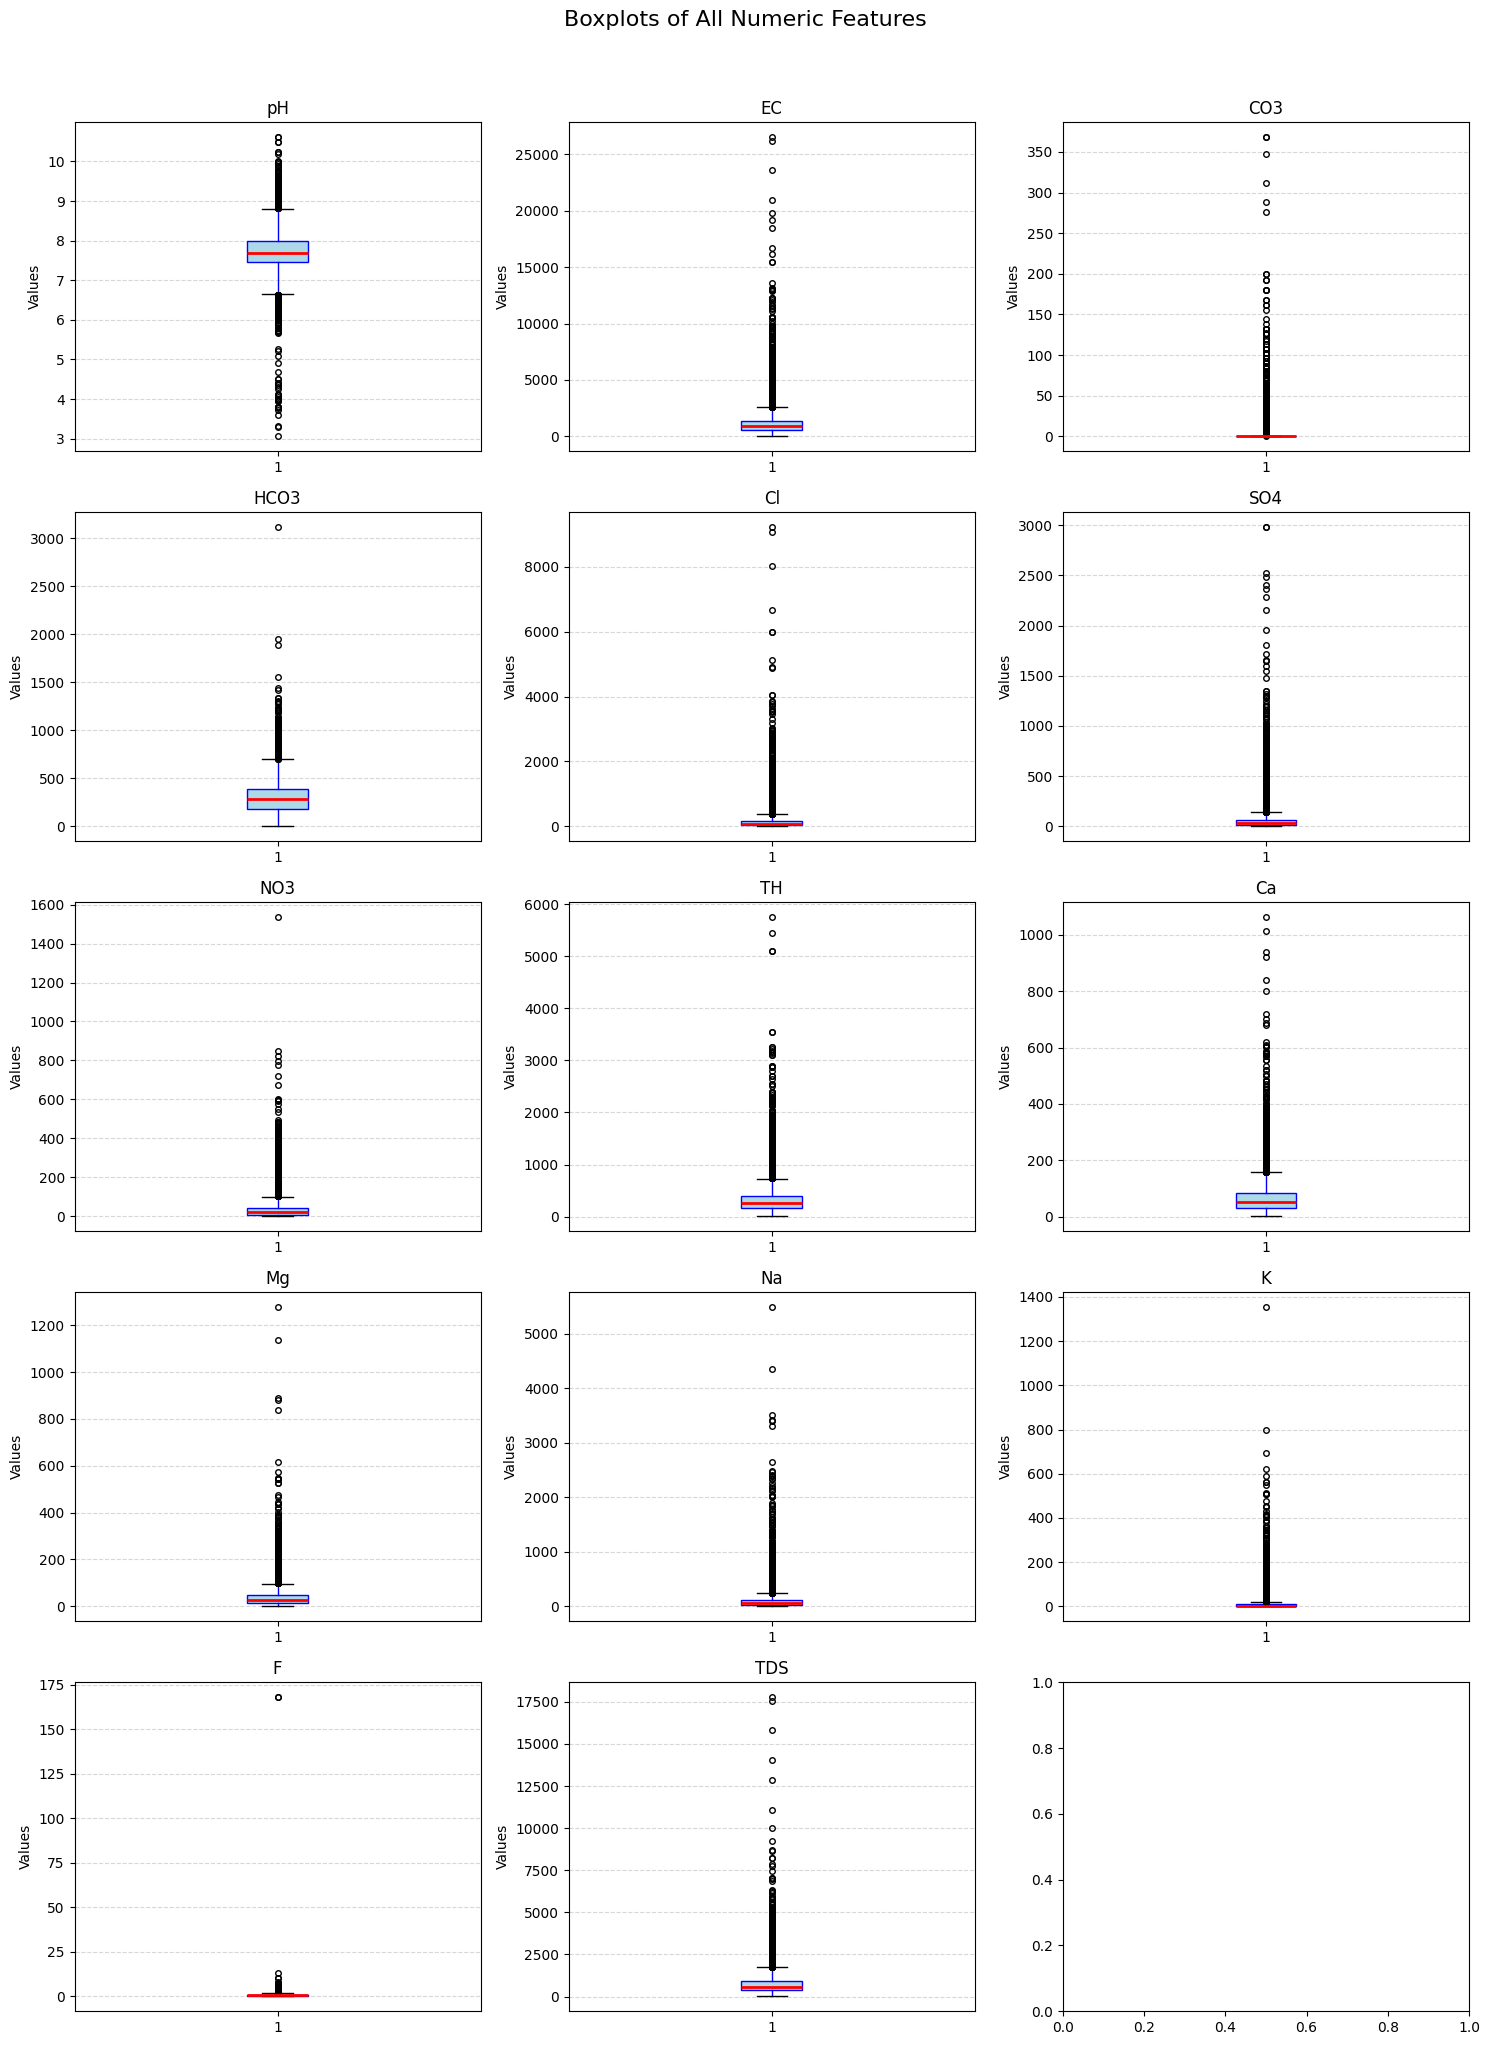

In [246]:
# Get all numeric columns automatically
numeric_cols = df.drop(cols_not_to_consider, axis=1).select_dtypes(include="number").columns

# Calculate grid size dynamically
n_cols = 3                                        # Number of columns in grid
n_rows = math.ceil(len(numeric_cols) / n_cols)   # Rows needed automatically

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()                             # Flatten 2D array → 1D for easy iteration

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(),             # dropna to avoid errors
                    patch_artist=True,
                    boxprops=dict(facecolor="lightblue", color="blue"),
                    medianprops=dict(color="red", linewidth=2),
                    flierprops=dict(marker="o", color="red", markersize=4),
                    whiskerprops=dict(color="blue"))
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel("Values")
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Boxplots of All Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [247]:
cap_value = df["F"].quantile(0.99)
print(f"Capping F at: {cap_value}")
df["F"] = df["F"].clip(upper=cap_value)

# Log transform skewed columns
skewed_cols = ["EC", "Cl", "SO4", "NO3", "TH", "Na", "K", "TDS", "F", "Mg", "Ca", "HCO3"]
df_log = df.copy()
df_log[skewed_cols] = df[skewed_cols].apply(lambda x: np.log1p(x))

Capping F at: 2.9


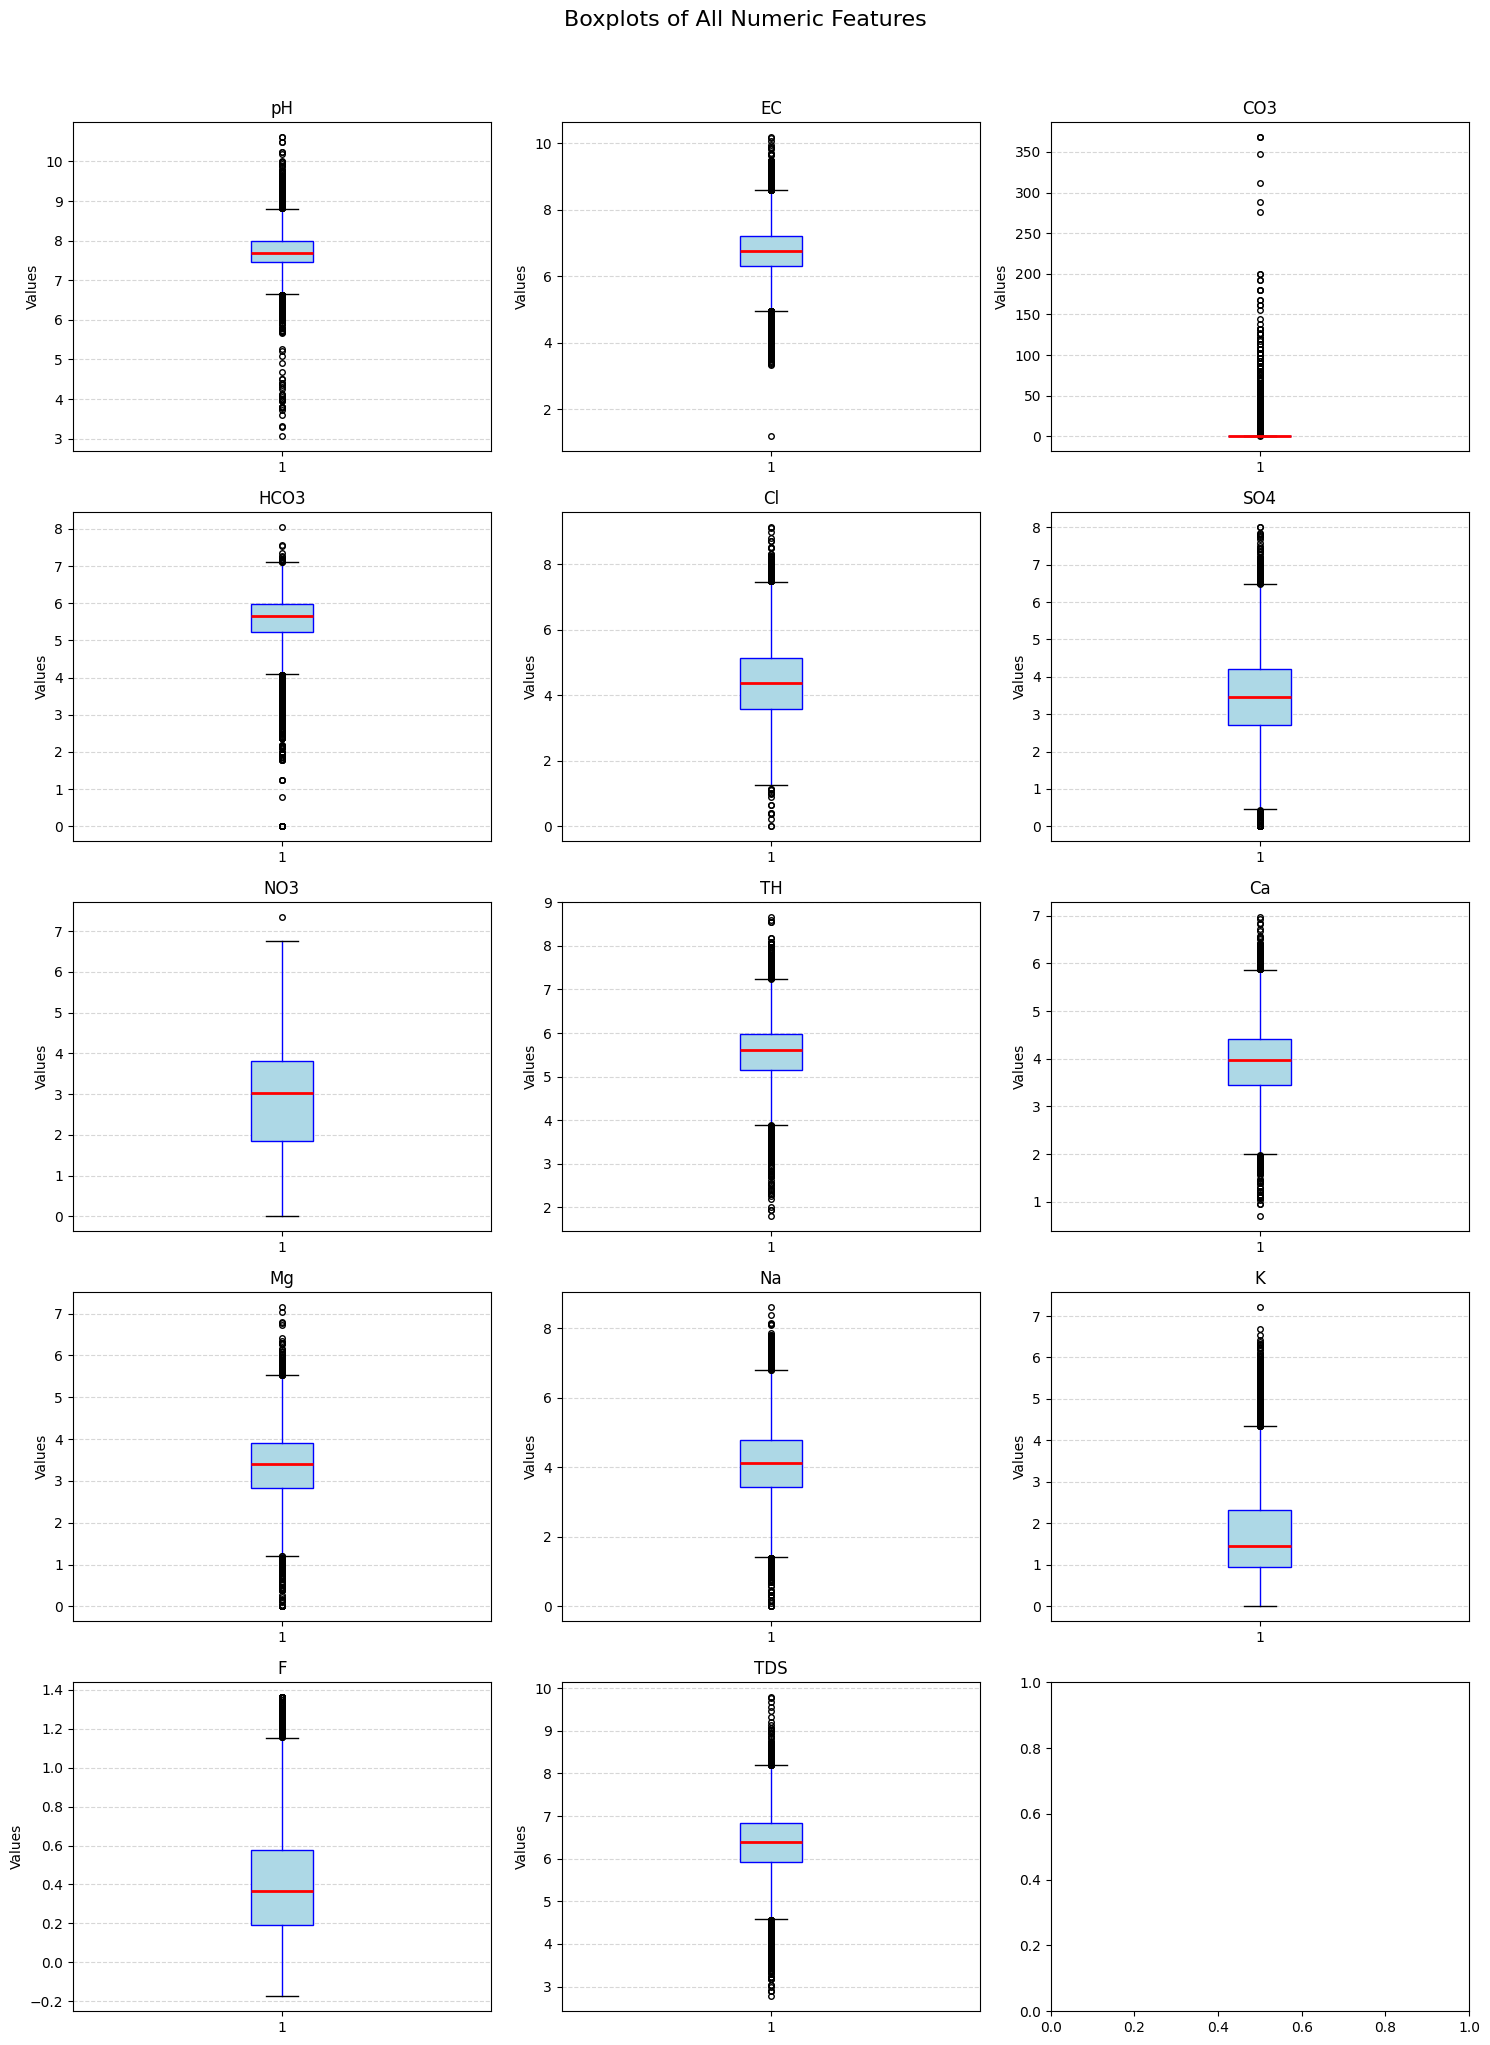

In [248]:
# Get all numeric columns automatically
numeric_cols = df_log.drop(cols_not_to_consider, axis=1).select_dtypes(include="number").columns

# Calculate grid size dynamically
n_cols = 3                                        # Number of columns in grid
n_rows = math.ceil(len(numeric_cols) / n_cols)   # Rows needed automatically

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()                             # Flatten 2D array → 1D for easy iteration

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_log[col].dropna(),             # dropna to avoid errors
                    patch_artist=True,
                    boxprops=dict(facecolor="lightblue", color="blue"),
                    medianprops=dict(color="red", linewidth=2),
                    flierprops=dict(marker="o", color="red", markersize=4),
                    whiskerprops=dict(color="blue"))
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel("Values")
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Boxplots of All Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [252]:
len(df_log[df_log["CO3"]==0])

13372

In [253]:
len(df_log)

14493

In [ ]:
# dropping the CO3, as most of the values are zero
df_log.drop("CO3", inplace=True, axis=1)

In [260]:
df_log[df_log.select_dtypes(include="number").columns].drop(cols_not_to_consider, axis=1).skew().sort_values(ascending=False)

K       1.128790
F       0.869629
Cl      0.203784
Na     -0.044879
NO3    -0.331575
SO4    -0.398124
Ca     -0.414146
EC     -0.414696
Mg     -0.461641
TDS    -0.630819
TH     -0.690421
pH     -0.765911
HCO3   -1.697875
dtype: float64

In [261]:
df_log.head()

,index,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
0,1,W254029084355301,Himachal Pradesh,Solan,nallagarh,jagatpur,31.159400,76.678500,2019,8.44,...,1.308333,4.442651,2.890372,2.397895,3.688879,1.223775,0.182322,5.572154,85.80466,Good
1,2,W193530074180001,Maharashtra,Ahmednagar,sangamner,kokangaon,74.300000,19.591667,2022,7.90,...,2.954910,6.144186,4.396915,4.180522,4.492001,0.955511,0.425268,5.921578,280.04130,Very Poor yet Drinkable
2,4,W251908084361501,Himachal Pradesh,Solan,nallagarh,baruna,31.154000,76.638400,2019,8.40,...,2.397895,4.762174,2.397895,2.944439,3.178054,0.693147,0.113329,5.572154,81.77860,Good
3,5,W192600074540001,Maharashtra,Ahmednagar,nevasa,vadala bhairoba,74.900000,19.433333,2022,7.55,...,4.169761,6.236370,4.763882,3.998201,4.578826,2.104134,0.165514,6.710523,376.42330,Unsuitable for Drinking
4,6,W222230071591001,Gujarat,Ahmedabad,dhandhuka,dhandhuka1,22.376073,71.987684,2020,8.20,...,5.398163,6.525030,4.290459,4.812184,7.233455,3.806662,1.360977,8.499233,1944.80480,Unsuitable for Drinking


In [263]:
df_log.drop("index", axis=1).to_csv("./water_quality_processed.csv", index=False)